# Task 1: Quantum Computing Part

In [ ]:
!pip install pennylane

## Question 1

implement a simple quantum operation with Cirq or Pennylane
1. With 5 qubits
2. Apply Hadamard operation on every qubit
3. Apply CNOT operation on (0, 1), (1,2), (2,3), (3,4)
4. SWAP (0, 4)
5. Rotate X with pi/2 on any qubit
6. lot the circuit

In [2]:
import pennylane as qml
import matplotlib.pyplot as plt
import math

dev = qml.device("default.qubit", wires=5)

In [3]:
@qml.qnode(dev)
def qn():
  for i in range(5):
    qml.Hadamard(wires = i)
  for j in range(4):
    qml.CNOT(wires = [j,j+1])
  qml.SWAP(wires = [0,4])
  qml.RX(math.pi/2,wires=2)
  return qml.state()

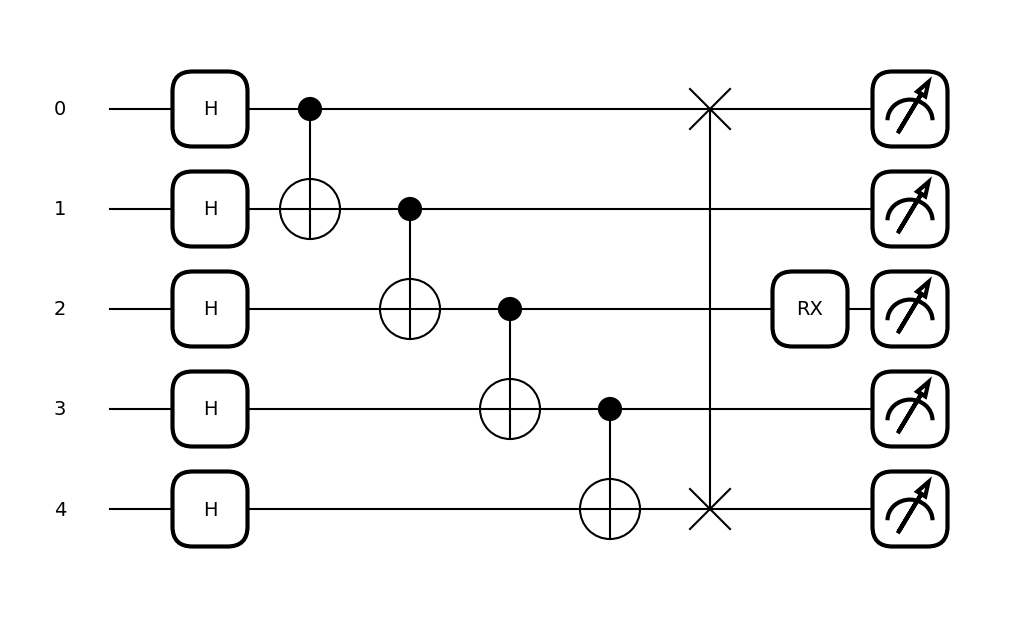

In [4]:
fig,ax = qml.draw_mpl(qn)()

## Question 2

1. Apply a Hadmard gate to the first qubit
2. rotate the second qubit by pi/3 around X
3. Apply Hadamard gate to the third and fourth qubit
4. Perform a swap test between the states of the first and second qubit |q1 q2> and the third and fourth qubit |q3 q4>


In [13]:
import pennylane as qml
from pennylane import numpy as np

dev = qml.device("default.qubit", wires=5)

@qml.qnode(dev)
def swap_test_circuit():
    qml.Hadamard(wires=0)
    qml.RX(np.pi / 3, wires=1)

    # Second pair (|q3 q4> on wires 2 and 3)
    qml.Hadamard(wires=2)
    qml.Hadamard(wires=3)

    # --- Swap Test ---

    # Put the ancilla (wire 4) in an equal superposition
    qml.Hadamard(wires=4)
    # Controlled-SWAP between the first qubits of each pair (wires 0 and 2)
    qml.CSWAP(wires=[4, 0, 2])
    # Controlled-SWAP between the second qubits of each pair (wires 1 and 3)
    qml.CSWAP(wires=[4, 1, 3])
    # Interfere the ancilla
    qml.Hadamard(wires=4)

    # Measure the probability distribution of the ancilla
    return qml.probs(wires=4)

# Execute the circuit
probs = swap_test_circuit()
fidelity = 2 * probs[0] - 1

print(f"Ancilla Probabilities (P(0), P(1)): {probs}")
print(f"Calculated Fidelity (Overlap Squared): {fidelity:.4f}")

Ancilla Probabilities (P(0), P(1)): [0.75 0.25]
Calculated Fidelity (Overlap Squared): 0.5000


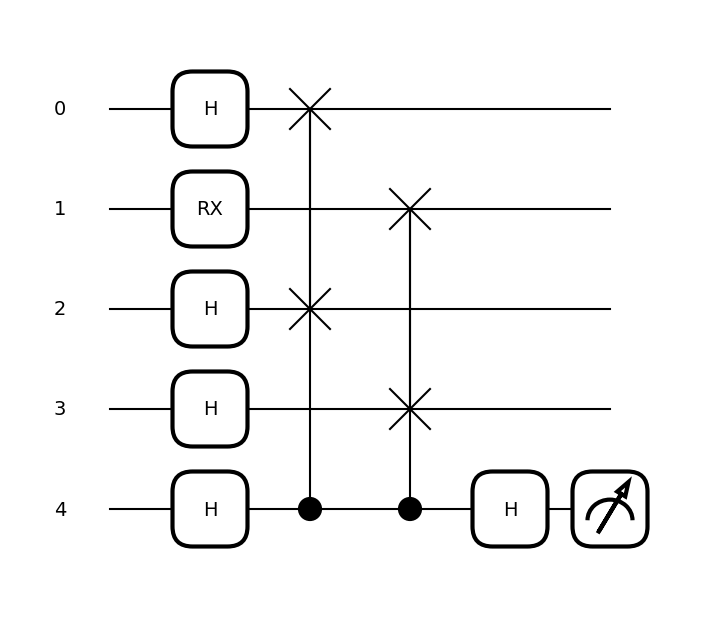

In [14]:
fig,ax = qml.draw_mpl(swap_test_circuit)()